## Monte Carlo CEP Simulation
Author: Zachary Lee
<hr>

In real life experiments, we cannot always take into account every variable that influences a system. For example, in my previous project "ProjectileMotion" the theorized value of where the projectile would impact was dependent on it's mass, launch angle, initial height, initial velocity, and it's drag constant. All of the above things were set properties of the projectile that do not change from each individual launch. In real-life testing, there are many things can influence the impact distance of a projectile, such as variable wind speed. What this means is that if you were to launch one projectile after another you'd find they don't always land in the same area. In fact, you might find one projectile land significantly closer than expected and another land significantly farther than expected. 

The Monte Carlo method addresses this by treating uncertainty as a feature rather than a problem. Instead of focusing on where the projectile lands, it focuses on where the projectile tends to land. By simulating thousands of individual projectiles, each with slightly randomized variables, we can map out the full distribution of impact points and calculate meaningful statistics. One of the most meaningful of these is the Circular Error Probable (CEP), which is the radius around the mean impact point within which half of all projectiles are expected to land. The Monte Carlo method is widely used throughout various STEM fields.

 * In Physics, you can simulate how photons and neutrons travel through a material, scatter, and get absorbed because each particle's path is probabilistic. This is used in nuclear reactor design and radiation shielding analysis.
 
 * In Technology, self-driving vehicles use the method to simulate thousands of possible future paths due to the amount of uncertainty from other vehicles, sensors, and road conditions. 
 
 * In Engineering, when launching a satellite into orbit, engineers cannot perfectly control every variable that influences the rocket's flight path due to variations in thrust output from different engines, atmospheric density, wind speeds at different altitudes, and sensor uncertainty.

 * In Mathematics, some integrals are impossible to solve analytically and are too computationally expensive, the Monte Carlo method estimated the value by randomly sampling points in the domain and averaging the function values, which is more efficient than traditional methods when many variables are involved.

 I will be using code from my ProjectileMotion project and will have the projectiles values match that of a large cannonball.

In [1]:
# Import and Constants Cell
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from scipy.integrate import solve_ivp

G = 9.81 # Acceleration due to gravity (m/s^2).
M = 14.51 # Mass of a large cannonball.
C = 0.00443 # lumped drag constant of a large cannonball.


In [2]:
# Definition Cell

def projectile_motion(t, components, wind):

    x, y, vx, vy = components

    # Speed relative to the air.
    vx_wind = vx - wind
    v_wind = np.sqrt(vx_wind**2 + vy**2)

    # Equations of motion.
    dxdt = vx
    dydt = vy
    ax = -(C/M) * v_wind * vx_wind
    ay = -G - (C/M) * v_wind * vy

    return [dxdt, dydt, ax, ay]

#--------------------------------------------------
# Detects when the projectile impact the ground.
#--------------------------------------------------

def impact(t, components, wind):
    return components[1] # returns the y position of the projectile, triggers when y = 0 (ground level).

impact.terminal = True # Stops integration at this event.
impact.direction = -1  # Only trigger when y is decreasing.

#--------------------------------------------------
# Physics Solver
#--------------------------------------------------

def simulate_projectile(v0, theta, wind):

    # Initial conditions.
    theta_rad = np.radians(theta)
    vx0 = v0 * np.cos(theta_rad)
    vy0 = v0 * np.sin(theta_rad)
    initial_conditions = [0, 0, vx0, vy0]

    # Time span for the simulation.
    t_span = (0, 200)  # Simulate for 200 seconds.
    t_eval = np.linspace(0, 200, 10000)  # Evaluate at 10000 points.

    # Solve the ODEs.
    solution = solve_ivp(projectile_motion, t_span, initial_conditions, args=(wind,), 
                         events=impact, t_eval=t_eval, max_step=0.1, dense_output=True)
    
    # Extracts the impact time and position if an impact occurred.
    if solution.t_events[0].size > 0:
        impact_time = solution.t_events[0][0]
        impact_position = solution.sol(impact_time)
        x_impact = impact_position[0]
        y_impact = impact_position[1]
    else:
        # Handler if impact event is not detected.
        x_impact = solution.y[0, -1]
        y_impact = solution.y[1, -1]

    return x_impact, y_impact



In [3]:
# Test Cell
x, y = simulate_projectile(100, 45, 0)
print(f"Impact position: x = {x:.2f} m")
print(f"Impact Height: y = {y:.2f} m")

Impact position: x = 826.68 m
Impact Height: y = -0.00 m


In [4]:
# Monte Carlo Simulation Cell

angle_nominal = 45.0 # degrees.
v0_nominal = 100.0   # m/s.
wind_nominal = 0.0   # m/s.

# Uncertainty (standard deviation)
angle_sigma = 0.5  # degrees.
v0_sigma = 1.5     # m/s.
wind_sigma = 3.0   # m/s.
range_sigma = 5.0  # m. Adds deviation to y-values.

# Number of Monte Carlo samples.
N = 5000 # I am going to keep this number low for now to avoid long computation times.

#--------------------------------------------------
# Distributions for the Monte Carlo simulation.
#--------------------------------------------------
np.random.seed(42)  # For reproducibility, without this, the results will be different each time you run the simulation.

angles = np.random.normal(angle_nominal, angle_sigma, N)
v0s = np.random.normal(v0_nominal, v0_sigma, N)
winds = np.random.normal(wind_nominal, wind_sigma, N)

#--------------------------------------------------
# Run the Monte Carlo simulation.
#--------------------------------------------------
x_impacts = np.zeros(N) # Creates an array to store the impact positions for each simulation. Increases computational speed.

# Loop through each sample and simulate the projectile motion.
for i in range(N):
    x_impacts[i], _ = simulate_projectile(v0s[i], angles[i], winds[i])

y_impacts = np.random.normal(0, range_sigma, N) # Prevents impact points forming a straight line.

print(f"Simulation complete: {N:,} trials run successfully.") # On my machines, it usually takes 1m 23.6s to complete.

Simulation complete: 5,000 trials run successfully.


In [5]:
#--------------------------------------------------
# CEP Calculation
#--------------------------------------------------

# Mean impact point
x_mean = np.mean(x_impacts)
y_mean = np.mean(y_impacts)

# Distance of each impact from the mean impact point.
distances = np.sqrt((x_impacts - x_mean)**2 + (y_impacts - y_mean)**2)

# Remember, CEP is the 50th percentile of distances.
CEP = np.percentile(distances, 50)

# Additional statistics
R90 = np.percentile(distances, 90) # Calculated the 90th percentile of the distances array.

print("=" * 45)
print("Monte Carlo CEP Analysis — Results")
print("=" * 45)
print(f"Trials completed:        {N:,}")
print(f"Nominal launch angle:    {angle_nominal}°")
print(f"Nominal launch speed:    {v0_nominal} m/s")
print(f"Mean impact distance:    {x_mean:.2f} m")
print(f"Std dev (downrange):     {np.std(x_impacts):.2f} m")
print(f"Std dev (cross-range):   {np.std(y_impacts):.2f} m")
print(f"CEP:                     {CEP:.2f} m")
print(f"90% radius (R90):        {R90:.2f} m")
print("=" * 45)

Monte Carlo CEP Analysis — Results
Trials completed:        5,000
Nominal launch angle:    45.0°
Nominal launch speed:    100.0 m/s
Mean impact distance:    826.39 m
Std dev (downrange):     22.90 m
Std dev (cross-range):   5.02 m
CEP:                     16.44 m
90% radius (R90):        38.17 m


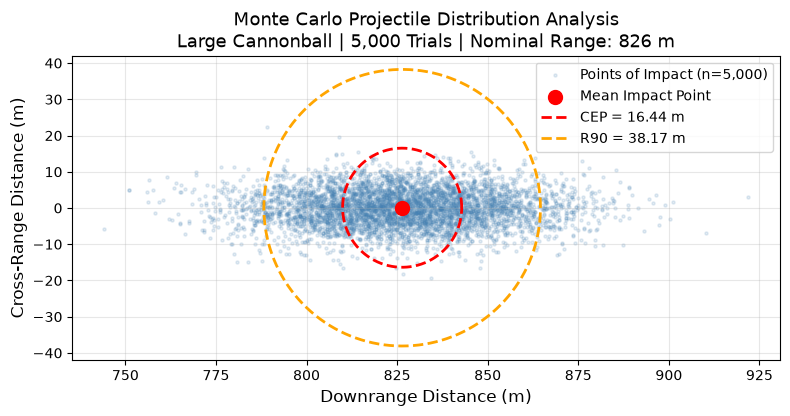

In [6]:
#--------------------------------------------------
# Impact Scatter Plot Cell
#--------------------------------------------------
fig, ax = plt.subplots(figsize=(8,8))

# Impact scatter
ax.scatter(x_impacts, y_impacts, alpha = 0.15, s=5, color="steelblue", label=f'Points of Impact (n={N:,})')

# Mean Impact Point
ax.scatter(x_mean, y_mean, color="red", s=100, zorder=5, label="Mean Impact Point")

# CEP circle
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(x_mean + CEP * np.cos(theta), y_mean + CEP * np.sin(theta), 'r--', linewidth=2, label=f'CEP = {CEP:.2f} m')

# R90 circle
ax.plot(x_mean + R90 * np.cos(theta), y_mean + R90 * np.sin(theta), 'orange', linewidth=2, linestyle='--', label=f'R90 = {R90:.2f} m')

ax.set_xlabel("Downrange Distance (m)", fontsize=12)
ax.set_ylabel("Cross-Range Distance (m)", fontsize=12)
ax.set_title("Monte Carlo Projectile Distribution Analysis\n" f'Large Cannonball | {N:,} Trials | Nominal Range: {x_mean:.0f} m', fontsize = 13)
ax.legend(fontsize=10)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/cep_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

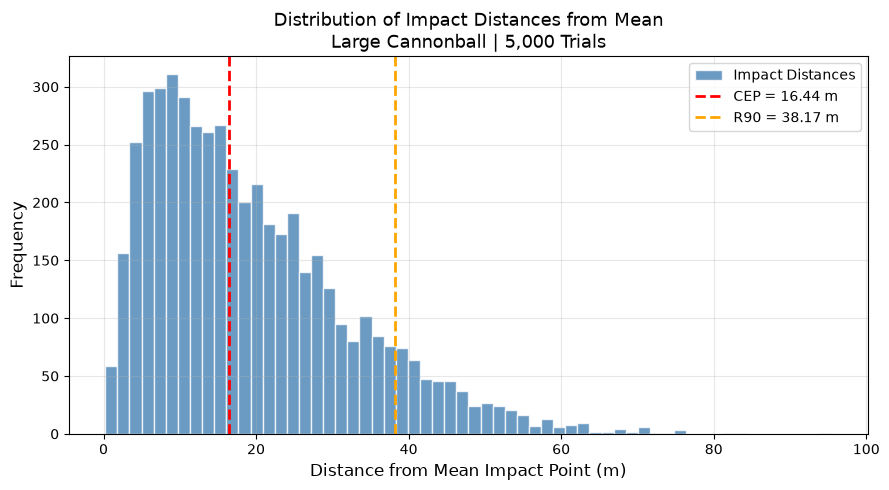

In [7]:
#--------------------------------------------------
# Distance Distribution Cell
#--------------------------------------------------
fig, ax = plt.subplots(figsize=(9,5))

ax.hist(distances, bins=60, color="steelblue", edgecolor="white", alpha=0.8, label="Impact Distances")

ax.axvline(CEP, color="red", linestyle="--", linewidth=2, label=f"CEP = {CEP:.2f} m")

ax.axvline(R90, color="orange", linestyle="--", linewidth=2, label=f"R90 = {R90:.2f} m")

ax.set_xlabel("Distance from Mean Impact Point (m)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Impact Distances from Mean\n" f"Large Cannonball | {N:,} Trials", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/cep_histogram.png', dpi=150, bbox_inches="tight")
plt.show()

In [8]:
#--------------------------------------------------
# Summary Statistics
#--------------------------------------------------
print("=" * 45)
print("  Monte Carlo CEP Analysis — Summary")
print("=" * 45)
print(f"  Projectile:              Cannonball")
print(f"  Mass:                    {M} kg")
print(f"  Drag Constant:           {C} kg/m")
print(f"  Trials completed:        {N:,}")
print(f"  Nominal launch angle:    {angle_nominal}°")
print(f"  Nominal launch speed:    {v0_nominal} m/s")
print(f"  Angle uncertainty:       ±{angle_sigma}°")
print(f"  Velocity uncertainty:    ±{v0_sigma} m/s")
print(f"  Wind uncertainty:        ±{wind_sigma} m/s")
print(f"  Cross-range sigma:       ±{range_sigma} m")
print("-" * 45)
print(f"  Mean impact distance:    {x_mean:.2f} m")
print(f"  Std dev (downrange):     {np.std(x_impacts):.2f} m")
print(f"  Std dev (cross-range):   {np.std(y_impacts):.2f} m")
print("-" * 45)
print(f"  CEP:                     {CEP:.2f} m")
print(f"  R90:                     {R90:.2f} m")
print("=" * 45)

  Monte Carlo CEP Analysis — Summary
  Projectile:              Cannonball
  Mass:                    14.51 kg
  Drag Constant:           0.00443 kg/m
  Trials completed:        5,000
  Nominal launch angle:    45.0°
  Nominal launch speed:    100.0 m/s
  Angle uncertainty:       ±0.5°
  Velocity uncertainty:    ±1.5 m/s
  Wind uncertainty:        ±3.0 m/s
  Cross-range sigma:       ±5.0 m
---------------------------------------------
  Mean impact distance:    826.39 m
  Std dev (downrange):     22.90 m
  Std dev (cross-range):   5.02 m
---------------------------------------------
  CEP:                     16.44 m
  R90:                     38.17 m


Animation saved to images/cep_animation.gif


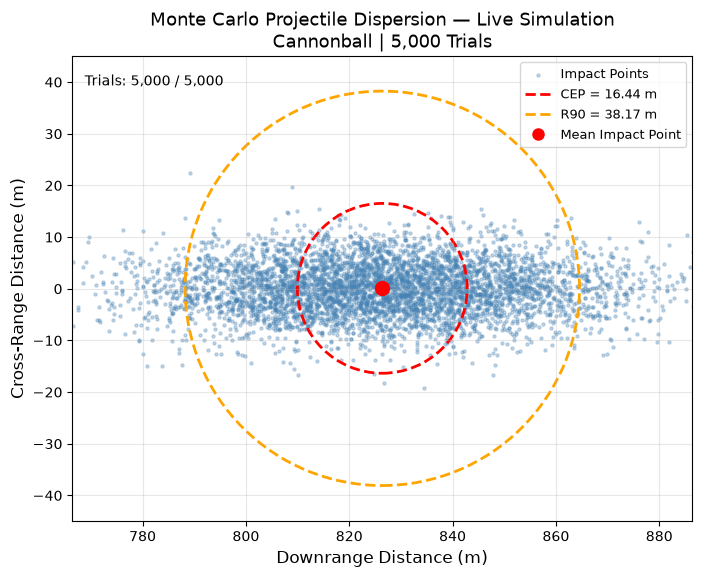

In [9]:
# --------------------------------
# Animation — Progressive Scatter
# --------------------------------
import matplotlib.animation as animation
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 8))

# Set axis limits with some padding
x_pad = 60
y_pad = 45
ax.set_xlim(x_mean - x_pad, x_mean + x_pad)
ax.set_ylim(y_mean - y_pad, y_mean + y_pad)

ax.set_xlabel("Downrange Distance (m)", fontsize=12)
ax.set_ylabel("Cross-Range Distance (m)", fontsize=12)
ax.set_title("Monte Carlo Projectile Dispersion — Live Simulation\n"
             "Cannonball | 5,000 Trials", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# Empty scatter to update
scatter = ax.scatter([], [], alpha=0.3, s=5, color="steelblue",
                     label="Impact Points")

# Mean point — hidden until end
mean_point = ax.scatter([], [], color="red", s=100, zorder=5)

# Trial counter text
counter_text = ax.text(0.02, 0.96, "", transform=ax.transAxes,
                       fontsize=10, verticalalignment="top")

# CEP circle — hidden until end
cep_circle = plt.Circle((x_mean, y_mean), CEP, color="red",
                         linestyle="--", linewidth=2,
                         fill=False, visible=False)
ax.add_patch(cep_circle)

# R90 circle — hidden until end
r90_circle = plt.Circle((x_mean, y_mean), R90, color="orange",
                         linestyle="--", linewidth=2,
                         fill=False, visible=False)
ax.add_patch(r90_circle)

# Static legend entries for CEP and R90
ax.plot([], [], color="red", linestyle="--", 
        linewidth=2, label=f"CEP = {CEP:.2f} m")
ax.plot([], [], color="orange", linestyle="--", 
        linewidth=2, label=f"R90 = {R90:.2f} m")
ax.plot([], [], color="red", marker="o", 
        linestyle="", markersize=8, label="Mean Impact Point")

ax.legend(loc="upper right", fontsize=9)

# --------------------------------
# Animation parameters
# --------------------------------
batch_size = 50      # points added per frame
n_frames   = N // batch_size  # total frames

def update(frame):
    end_idx = (frame + 1) * batch_size

    # Update scatter data
    scatter.set_offsets(
        np.column_stack((x_impacts[:end_idx], y_impacts[:end_idx]))
    )

    # Update counter
    counter_text.set_text(f"Trials: {end_idx:,} / {N:,}")

    # Reveal mean point and circles on final frame
    if frame == n_frames - 1:
        mean_point.set_offsets([[x_mean, y_mean]])
        cep_circle.set_visible(True)
        r90_circle.set_visible(True)

    return scatter, mean_point, cep_circle, r90_circle, counter_text

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=50,       # ms between frames
    blit=True
)

# Save as GIF
anim.save("images/cep_animation.gif",
          writer="pillow",
          fps=20,
          dpi=100)

print("Animation saved to images/cep_animation.gif")
plt.show()